In [55]:
from dataloader import *
from augmentations import *
from models import *
from training import *
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from statistics import mean, stdev
import copy
import ast
import seaborn as sns
from IPython.display import display, HTML

## Models

In [57]:
models = ["SmallCNN", 
          "ResNet",
          "DenseNet121", 
          "VGG16_BN", 
           ]

## Experiment loop for hyperparameter selection 

In [3]:
# choosing hyperparameters for grid search
params = {
    "batch_size": [8, 32, 128],
    "learning_rate": [1e-3, 1e-4, 1e-5],
    "optimizer": ['Adam', 'SGD'],
    "dropout": [0.2, 0.5],
    "weight_decay": [0, 1e-3, 0.5]
}

experiment_grid = [dict(zip(params.keys(), v)) for v in product(*params.values())]

In [4]:
def run_experiment(model_name, experiment_config, augmentation=None, cutmix_collate_fn=None, epoch_number=2, train_size=9000, test_size=9000):
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # model
    current_dropout = experiment_config.get("dropout", 0.2)
    model = get_model(model_name, dropout_rate=current_dropout)   
    model.to(device)

    # optimizer
    if experiment_config["optimizer"] == "Adam":
        optimizer = torch.optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=experiment_config["learning_rate"],
            weight_decay=experiment_config["weight_decay"]
        )
    else:
        optimizer = torch.optim.SGD(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=experiment_config["learning_rate"],
            weight_decay=experiment_config["weight_decay"],
            momentum=0.9
        )

    transformations = basic_transforms(augmentation_type=augmentation, model_type=model_name)

    train_dataset = get_train_dataset(transform=transformations)
    val_dataset, test_dataset = get_val_train_dataset(model_type=model_name)

    train_dataset = get_subset(train_dataset, train_size)
    val_dataset = get_subset(val_dataset, test_size)
    test_dataset = get_subset(test_dataset, test_size)

    train_loader = get_train_dataloaders(
        train_dataset,
        collate_fn=cutmix_collate_fn,
        batch_size=experiment_config["batch_size"]
    )
    
    val_loader, test_loader = get_val_test_dataloaders(
        val_dataset, test_dataset,
        batch_size=experiment_config["batch_size"]
    )

    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    best_model_weights = None
    best_val_metrics = {}

    for epoch in range(epoch_number):

        loss_score = train(model, train_loader, optimizer, criterion, device)
        scores = validate(model, val_loader, device, criterion)

        print(f"Epoch number: {epoch}; training loss: {loss_score:.5f}; val loss: {scores['loss']:.5f}")

        if scores['loss'] < best_val_loss:
            best_val_loss = scores['loss']
            best_model_weights = copy.deepcopy(model.state_dict())
            
            best_val_metrics = {f"val_{k}": v for k, v in scores.items()}

    print("Loading best model weights for testing...")
    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)

    raw_test_scores = validate(model, test_loader, device, criterion)
    
    test_scores = {f"test_{k}": v for k, v in raw_test_scores.items()}

    return {**best_val_metrics, **test_scores}

## Checking the big configuration grid on smaller dataset (10%)
### Using only SmallCNN and Resnet 

In [ ]:
results = []

for model in models:
    for i, config in enumerate(experiment_grid):

        print(f"Configuration number {i+1}, model: {model} config params: {config}")

        if model == "SmallCNN":
            epoch_number = 50
        elif model == "ResNet":
            epoch_number = 20
        else:
            break

        score = run_experiment(model, config, epoch_number=epoch_number, train_size=900, test_size=900)
        d = {
            "model": model,
            "config": config}
        results.append({
            **d, **score
        })

df = pd.DataFrame(results)
df.to_csv("results/tenth_of_database_results.csv", index=False)

In [5]:
# saving configurations for 5 models with best accuracy on validation set from a csv file with results 

experiment_grid_small = {}
for model in models:
    results_df = pd.read_csv("tenth_of_database_results.csv")
    results_df = results_df[results_df["model"] == model]
    results_df = results_df.sort_values(by="mean_acc", ascending=False).head(5)
    #change config from string to dict
    results_df["config"] = results_df["config"].apply(lambda x: ast.literal_eval(x))
    experiment_grid_small[model] = results_df["config"].tolist()

# add the Resnet configs to experiment_grid_small for models DenseNet121 and VGG16_BN
for model in models:
    if model == "DenseNet121" or model == "VGG16_BN":
        experiment_grid_small[model] = experiment_grid_small["ResNet"]

print(f"Model: {model}, best configs: {experiment_grid_small[model]}, best acc: {results_df['mean_acc'].tolist()}")

Model: VGG16_BN, best configs: [{'batch_size': 32, 'learning_rate': 0.001, 'optimizer': 'SGD', 'dropout': 0.5, 'weight_decay': 0.001}, {'batch_size': 32, 'learning_rate': 0.001, 'optimizer': 'SGD', 'dropout': 0.5, 'weight_decay': 0}, {'batch_size': 32, 'learning_rate': 0.001, 'optimizer': 'Adam', 'dropout': 0.2, 'weight_decay': 0.001}, {'batch_size': 32, 'learning_rate': 0.001, 'optimizer': 'SGD', 'dropout': 0.2, 'weight_decay': 0}, {'batch_size': 32, 'learning_rate': 0.001, 'optimizer': 'Adam', 'dropout': 0.5, 'weight_decay': 0}], best acc: []


## Training on full data and more epochs but considering top5 configs from previous experiment
### For pretrained models we applied the Resnet configs (didn't have enough time to train all models in previous experiment)

In [ ]:
results = []

for model in models:
    for i, config in enumerate(experiment_grid_small[model]): 
        print(f"Configuration number {i+1}, model: {model} config params: {config}")

        if model == "SmallCNN":
            epoch_number = 50 
        else:
            epoch_number = 20
        
        score = run_experiment(model, config, epoch_number=epoch_number, train_size=9000, test_size=9000)
        d = {
            "model": model,
            "config": config}
        results.append({
            **d, **score
        })

df = pd.DataFrame(results)
df.to_csv("results/whole_database_results.csv", index=False)

### Defining example confs for augmentation and fewshot testing

In [ ]:
example_conf_resnet = {'batch_size': 32, 'learning_rate': 0.01, 'optimizer': 'SGD', 'dropout': 0.2, 'weight_decay': 0.0001}
example_conf_vgg16 = {'batch_size': 32, 'learning_rate': 0.01, 'optimizer': 'SGD', 'dropout': 0.5, 'weight_decay': 0.0001}
example_conf_densenet = {'batch_size': 32, 'learning_rate': 0.001, 'optimizer': 'Adam', 'dropout': 0.2, 'weight_decay': 0.0001}
example_conf_smallcnn = {'batch_size': 256, 'learning_rate': 0.001, 'optimizer': 'Adam', 'dropout': 0.1, 'weight_decay': 0.0001}

example_confs = {"ResNet": example_conf_resnet, "DenseNet121": example_conf_densenet, "VGG16_BN": example_conf_vgg16, "SmallCNN": example_conf_smallcnn}

## Few-shot learning

In [ ]:
shot_sizes = [1, 10, 50] 
models_to_test = ["SmallCNN", "ResNet", "DenseNet121", "VGG16_BN"]

fewshot_results = []

for shots in shot_sizes:
    for model_name in models_to_test:
        print(f"\nUruchamiam {shots}-shot learning dla modelu {model_name}...")

        if model_name == "SmallCNN":
            epoch_number = 50
        else:
            epoch_number = 10

        score = run_experiment(
            model_name=model_name,
            experiment_config=example_confs[model_name],
            augmentation=None,
            epoch_number=epoch_number,
            train_size=shots,
            test_size=9000
        )
        
        fewshot_results.append({
            "model": model_name,
            "shots": shots,
            "test_accuracy": score["test_accuracy"]
        })

df_fewshot = pd.DataFrame(fewshot_results)
df_fewshot.to_csv("results/fewshot_results.csv", index=False)

## Auqmentation experiments

In [10]:
# standard operations
basic_augmentations = ["flip", "shift", "rotation", None]
# more advanced data augmentation
advanced_augmentations = 'cutmix' 

In [ ]:
results_augm = []

for model_name in models:
    if model_name == "SmallCNN":
        current_epochs = 50
    else:
        current_epochs = 10

    for augm in basic_augmentations:

        # Ładniejsze wypisywanie dla baseline'u
        augm_label = augm if augm is not None else "baseline (brak)"
        print(f"\n{'='*50}")
        print(f"Rozpoczynam eksperyment: Model: {model_name} | Augmentation: {augm_label}")
        print(f"{'='*50}")

        # Wywołanie z jawnym podaniem epok i całego zbioru 
        score = run_experiment(
            model_name=model_name,
            experiment_config=example_confs[model_name], 
            augmentation=augm, 
            cutmix_collate_fn=None,
            epoch_number=current_epochs,        
            train_size=9000,
            test_size=9000
        )
        
        d = {
            "model": model_name,
            "augmentation": augm_label
        }
        
        results_augm.append({**d, **score})

    print(f"\n{'='*50}")
    print(f"Rozpoczynam eksperyment: Model: {model_name} | Augmentation: cutmix")
    print(f"{'='*50}")
    
    score = run_experiment(
        model_name=model_name,
        experiment_config=example_confs[model_name], 
        augmentation=None, # Przy cutmix nie nakładamy bazowych transformacji
        cutmix_collate_fn=cutmix_collate_fn,
        epoch_number=current_epochs,
        train_size=9000,
        test_size=9000
    )
    
    d = {
        "model": model_name,
        "augmentation": 'cutmix'
    }
        
    results_augm.append({**d, **score})

df_results = pd.DataFrame(results_augm)
print("\nGotowe! Wyniki eksperymentów:")
print(df_results)
df_results.to_csv("results/wyniki_augmentacji.csv", index=False)

# Visualizations and experiment analysis

### Ranking models in augmentation and configs experiments

In [ ]:
def format_short_config(config_str):
    try:
        c = ast.literal_eval(config_str)
        lr = f"{c.get('learning_rate', 0):.0e}" if c.get('learning_rate', 0) < 0.01 else c.get('learning_rate', '')
        return f"Opt: {c.get('optimizer', '')}, LR: {lr}, BS: {c.get('batch_size', '')}"
    except Exception:
        return "Config"

results = pd.read_csv("results/whole_database_results.csv")
results['config_short'] = results['config'].apply(format_short_config)

for model in models:
    display(HTML(f"<h3 style='color: #2c3e50; border-bottom: 2px solid #2c3e50; padding-bottom: 5px; margin-top: 20px;'>Hyperparameter Ranking for model: <b>{model}</b></h3>"))
    model_df = results[results["model"] == model]
    sorted_df = model_df.sort_values(by="test_accuracy", ascending=False).reset_index(drop=True)
    columns_to_show = ["config_short", "val_accuracy", "val_precision", "val_recall", "val_f1", "test_loss", "test_accuracy", "test_precision", "test_recall", "test_f1"]
    display_df = sorted_df[columns_to_show].head(10)
    styled_df = display_df.style.format(precision=4).hide(axis="index")\
        .highlight_max(subset=['test_accuracy'], color="#0a0267") 
    display(styled_df)

config_short,val_accuracy,val_precision,val_recall,val_f1,test_loss,test_accuracy,test_precision,test_recall,test_f1
"Opt: SGD, LR: 1e-03, BS: 8",0.4101,0.4864,0.4101,0.3918,7.7756,0.4310,0.4967,0.4310,0.4140
"Opt: Adam, LR: 1e-03, BS: 8",0.3964,0.4870,0.3964,0.3834,8.9555,0.3925,0.4877,0.3925,0.3857
"Opt: Adam, LR: 1e-03, BS: 8",0.3674,0.4314,0.3674,0.3483,31.8415,0.3585,0.4133,0.3585,0.3381
"Opt: Adam, LR: 1e-03, BS: 8",0.3545,0.4136,0.3545,0.3403,30.1048,0.3558,0.3896,0.3558,0.3383
"Opt: SGD, LR: 1e-03, BS: 8",0.3495,0.4043,0.3495,0.3282,32.9984,0.3336,0.3717,0.3336,0.3184


config_short,val_accuracy,val_precision,val_recall,val_f1,test_loss,test_accuracy,test_precision,test_recall,test_f1
"Opt: SGD, LR: 1e-03, BS: 32",0.7609,0.7640,0.7609,0.7601,0.6604,0.7674,0.7680,0.7674,0.7669
"Opt: Adam, LR: 1e-03, BS: 32",0.7585,0.7641,0.7585,0.7577,0.6653,0.7673,0.7706,0.7673,0.7672
"Opt: SGD, LR: 1e-03, BS: 32",0.7611,0.7652,0.7611,0.7607,0.6697,0.7660,0.7676,0.7660,0.7646
"Opt: SGD, LR: 1e-03, BS: 32",0.7589,0.7627,0.7589,0.7577,0.6806,0.7614,0.7657,0.7614,0.7596
"Opt: Adam, LR: 1e-03, BS: 32",0.7608,0.7640,0.7608,0.7603,0.6797,0.7613,0.7653,0.7613,0.7616


config_short,val_accuracy,val_precision,val_recall,val_f1,test_loss,test_accuracy,test_precision,test_recall,test_f1
"Opt: SGD, LR: 1e-03, BS: 32",0.7937,0.7935,0.7937,0.7933,0.5901,0.7912,0.7911,0.7912,0.7909
"Opt: Adam, LR: 1e-03, BS: 32",0.7896,0.7909,0.7896,0.7894,0.5975,0.7884,0.7897,0.7884,0.7882
"Opt: Adam, LR: 1e-03, BS: 32",0.7794,0.7788,0.7794,0.7785,0.6318,0.7775,0.7772,0.7775,0.7767
"Opt: SGD, LR: 1e-03, BS: 32",0.7770,0.7758,0.7770,0.7756,0.6405,0.7759,0.7748,0.7759,0.7746
"Opt: SGD, LR: 1e-03, BS: 32",0.7769,0.7759,0.7769,0.7760,0.6425,0.7759,0.7753,0.7759,0.7752


config_short,val_accuracy,val_precision,val_recall,val_f1,test_loss,test_accuracy,test_precision,test_recall,test_f1
"Opt: SGD, LR: 1e-03, BS: 32",0.7621,0.7661,0.7621,0.7607,0.6652,0.7614,0.7653,0.7614,0.7603
"Opt: SGD, LR: 1e-03, BS: 32",0.7560,0.7571,0.7560,0.7546,0.6776,0.7581,0.7593,0.7581,0.7569
"Opt: Adam, LR: 1e-03, BS: 32",0.7540,0.7558,0.7540,0.7536,0.6923,0.7553,0.7573,0.7553,0.7550
"Opt: SGD, LR: 1e-03, BS: 32",0.7532,0.7568,0.7532,0.7533,0.6909,0.7528,0.7564,0.7528,0.7530
"Opt: Adam, LR: 1e-03, BS: 32",0.7492,0.7517,0.7492,0.7471,0.7155,0.7498,0.7529,0.7498,0.7480


In [61]:
results_augm = pd.read_csv("results/wyniki_augmentacji.csv")

for model in models:
    display(HTML(f"<h3 style='color: #16a085; border-bottom: 2px solid #16a085; padding-bottom: 5px; margin-top: 20px;'>Augmentation Ranking for model: <b>{model}</b></h3>"))
    model_df = results_augm[results_augm["model"] == model]
    sorted_df = model_df.sort_values(by="test_accuracy", ascending=False).reset_index(drop=True)
    columns_augm = ["augmentation", "test_accuracy", "val_accuracy", "test_f1", "test_precision", "test_recall"]
    display_df = sorted_df[columns_augm]
    styled_df = display_df.style.format(precision=4).hide(axis="index").highlight_max(subset=['test_accuracy'], color='#d4edda')\
        .highlight_max(subset=['test_accuracy'], color="#0a0267") 
    display(styled_df)

augmentation,test_accuracy,val_accuracy,test_f1,test_precision,test_recall
baseline (brak),0.5898,0.5924,0.5880,0.5870,0.5898
rotation,0.5783,0.5809,0.5779,0.5789,0.5783
flip,0.5388,0.5403,0.5364,0.5385,0.5388
shift,0.5241,0.5258,0.5149,0.5249,0.5241
cutmix,0.5181,0.5185,0.5111,0.5090,0.5181


augmentation,test_accuracy,val_accuracy,test_f1,test_precision,test_recall
baseline (brak),0.8003,0.8026,0.8003,0.8170,0.8003
shift,0.7971,0.8000,0.7969,0.8098,0.7971
rotation,0.7937,0.7966,0.7947,0.8056,0.7937
cutmix,0.7745,0.7764,0.7760,0.7897,0.7745
flip,0.7673,0.7710,0.7693,0.7863,0.7673


augmentation,test_accuracy,val_accuracy,test_f1,test_precision,test_recall
baseline (brak),0.7890,0.7909,0.7879,0.7887,0.7890
shift,0.7832,0.7844,0.7824,0.7832,0.7832
rotation,0.7783,0.7812,0.7772,0.7779,0.7783
cutmix,0.7681,0.7679,0.7670,0.7693,0.7681
flip,0.7671,0.7699,0.7662,0.7687,0.7671


augmentation,test_accuracy,val_accuracy,test_f1,test_precision,test_recall
baseline (brak),0.7357,0.7364,0.7362,0.7445,0.7357
rotation,0.7297,0.7304,0.7282,0.7336,0.7297
shift,0.7168,0.7183,0.7164,0.7319,0.7168
flip,0.7058,0.7092,0.7034,0.7110,0.7058
cutmix,0.6749,0.6768,0.6734,0.7121,0.6749


In [30]:
# laoding saved experiments results
configs_results = pd.read_csv("results/whole_database_results.csv")
augmentation_results = pd.read_csv("results/wyniki_augmentacji.csv")
fewshot_results = pd.read_csv("results/fewshot_results.csv")
small_data_results = pd.read_csv("results/tenth_of_database_results.csv")

## Plots

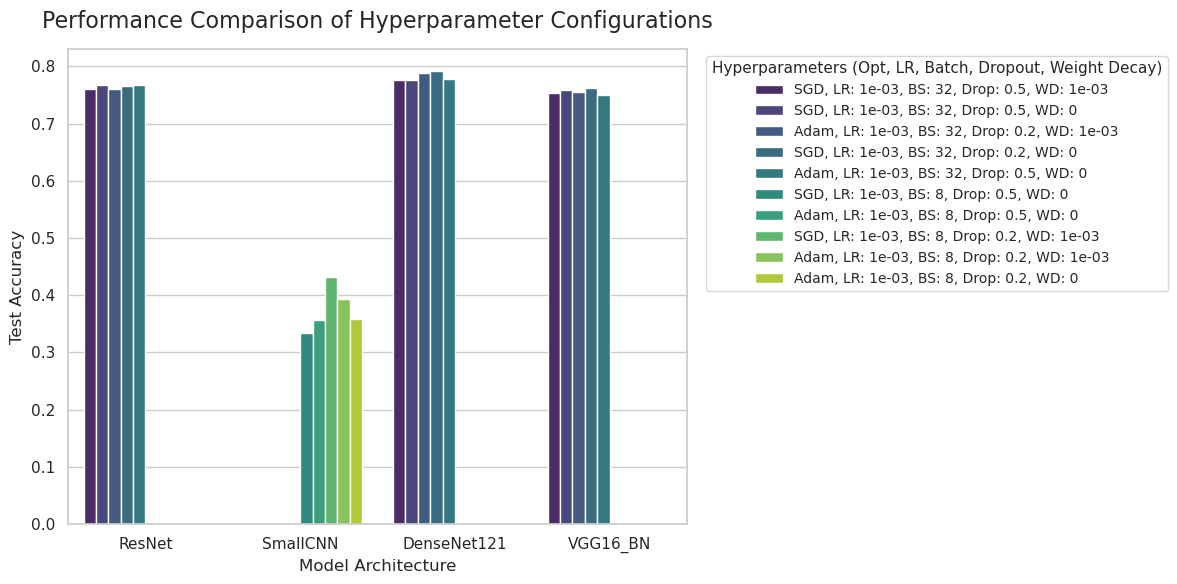

In [ ]:
sns.set_theme(style="whitegrid", palette="muted")

def format_config_string(config_str):
    """
    Parses the dictionary string and returns a compact, readable label for the legend.
    Example output: "Adam, LR: 1e-03, BS: 32, Drop: 0.2"
    """
    try:
        c = ast.literal_eval(config_str)
        lr = f"{c.get('learning_rate', 0):.0e}" if c.get('learning_rate', 0) < 0.01 else c.get('learning_rate', '')
        wd = f"{c.get('weight_decay', 0):.0e}" if 0 < c.get('weight_decay', 0) < 0.1 else c.get('weight_decay', 0)
        
        return f"{c.get('optimizer', 'Opt')}, LR: {lr}, BS: {c.get('batch_size', '')}, Drop: {c.get('dropout', '')}, WD: {wd}"
    except Exception:
        return str(config_str)[:45] + "..."

def plot_configs(df):
    plt.figure(figsize=(12, 6))
    
    plot_df = df.copy()
    
    plot_df['config_formatted'] = plot_df['config'].apply(format_config_string)
    
    ax = sns.barplot(
        data=plot_df, 
        x="model", 
        y="test_accuracy", 
        hue="config_formatted", 
        palette="viridis"
    )
    
    plt.title("Performance Comparison of Hyperparameter Configurations", fontsize=16, pad=15)
    plt.xlabel("Model Architecture", fontsize=12)
    plt.ylabel("Test Accuracy", fontsize=12)
    
    plt.legend(
        title="Hyperparameters (Opt, LR, Batch, Dropout, Weight Decay)", 
        bbox_to_anchor=(1.02, 1), 
        loc='upper left',
        fontsize=10,
        title_fontsize=11
    )
    
    plt.tight_layout()
    
    
    plt.savefig("figures/plot_1_configurations.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_configs(configs_results)

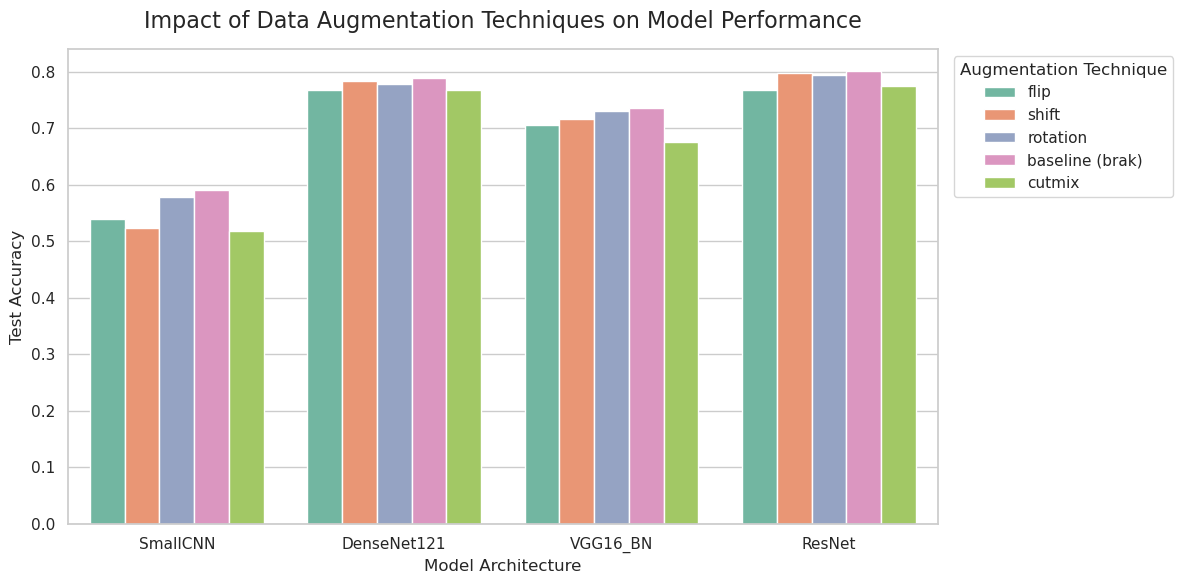

In [ ]:
def plot_augmentations(df):
    plt.figure(figsize=(12, 6))
    
    ax = sns.barplot(
        data=df, 
        x="model", 
        y="test_accuracy", 
        hue="augmentation", 
        palette="Set2" 
    )
    
    plt.title("Impact of Data Augmentation Techniques on Model Performance", fontsize=16, pad=15)
    plt.xlabel("Model Architecture", fontsize=12)
    plt.ylabel("Test Accuracy", fontsize=12)
    
    plt.legend(title="Augmentation Technique", bbox_to_anchor=(1.01, 1), loc='upper left')
    
    plt.tight_layout()
    
    plt.savefig("figures/plot_2_augmentations.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_augmentations(augmentation_results)

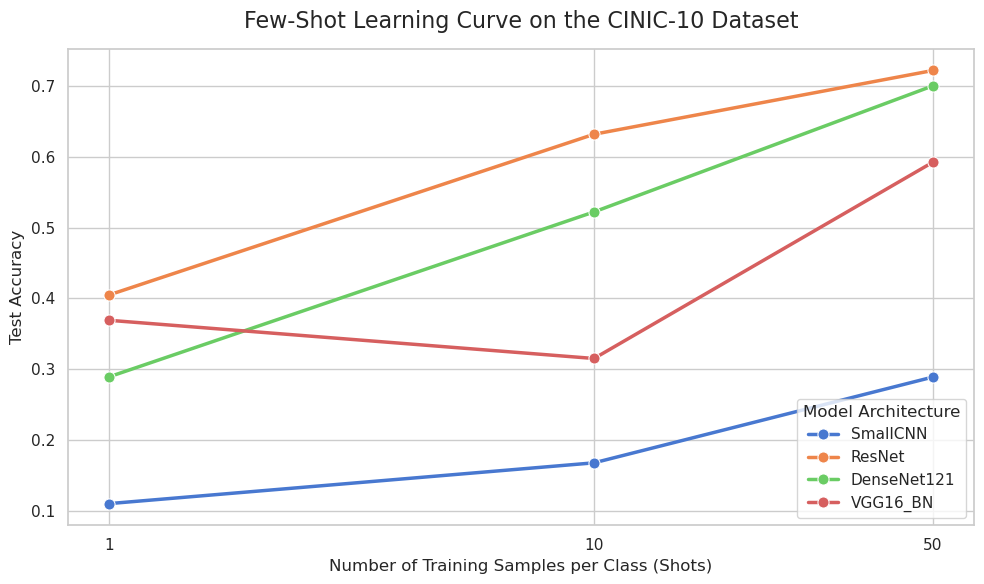

In [ ]:
def plot_fewshot(df):
    plt.figure(figsize=(10, 6))
    
    ax = sns.lineplot(
        data=df, 
        x="shots", 
        y="test_accuracy", 
        hue="model", 
        marker="o",
        linewidth=2.5,
        markersize=8
    )
    
    plt.title("Few-Shot Learning Curve on the CINIC-10 Dataset", fontsize=16, pad=15)
    plt.xlabel("Number of Training Samples per Class (Shots)", fontsize=12)
    plt.ylabel("Test Accuracy", fontsize=12)
    
    plt.xscale('log')
    
    shots_values = sorted(df['shots'].unique())
    plt.xticks(shots_values, labels=[str(int(x)) for x in shots_values])
    
    plt.legend(title="Model Architecture", loc='lower right') 
    
    plt.tight_layout()
    
    plt.savefig("figures/plot_3_fewshot.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_fewshot(fewshot_results)

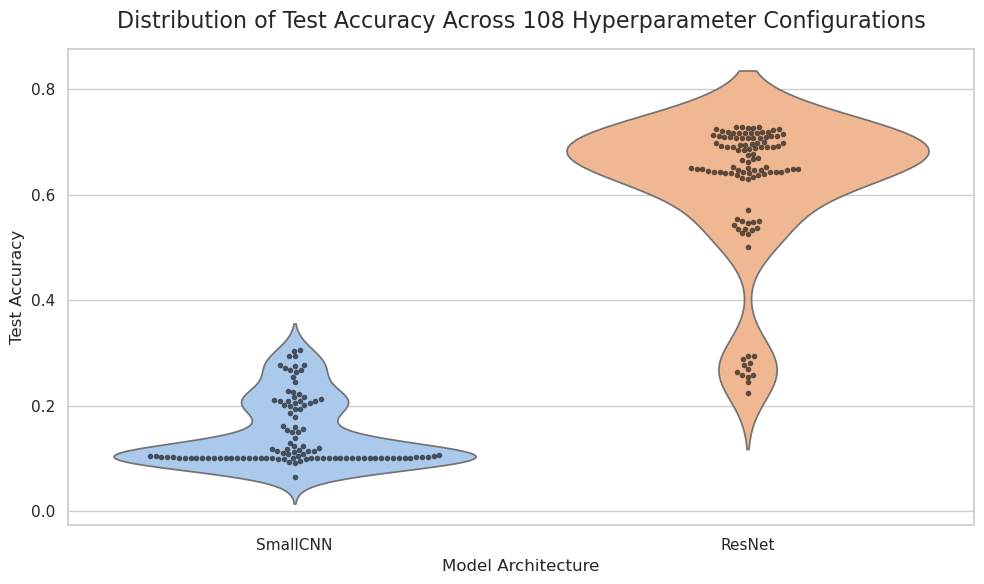

In [ ]:
def plot_hyperparameter_distribution(df):
    plt.figure(figsize=(10, 6))
    
    #tutaj używana jest inna nazwa kolumny, ponieważ ramka ta była generowana dużo wcześniej niż pozostałe
    sns.violinplot(
        data=df, 
        x="model", 
        y="accuracy", 
        hue="model",
        palette="pastel", 
        inner=None, 
        legend=False
    )
    
    sns.swarmplot(
        data=df, 
        x="model", 
        y="accuracy", 
        color="black", 
        alpha=0.6, 
        size=4
    )
    
    plt.title("Distribution of Test Accuracy Across 108 Hyperparameter Configurations", fontsize=16, pad=15)
    plt.xlabel("Model Architecture", fontsize=12)
    plt.ylabel("Test Accuracy", fontsize=12)
    
    plt.tight_layout()
    
    plt.savefig("figures/plot_4_hyperparameter_distribution.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_hyperparameter_distribution(small_data_results)

Unpacking configurations for plotting...


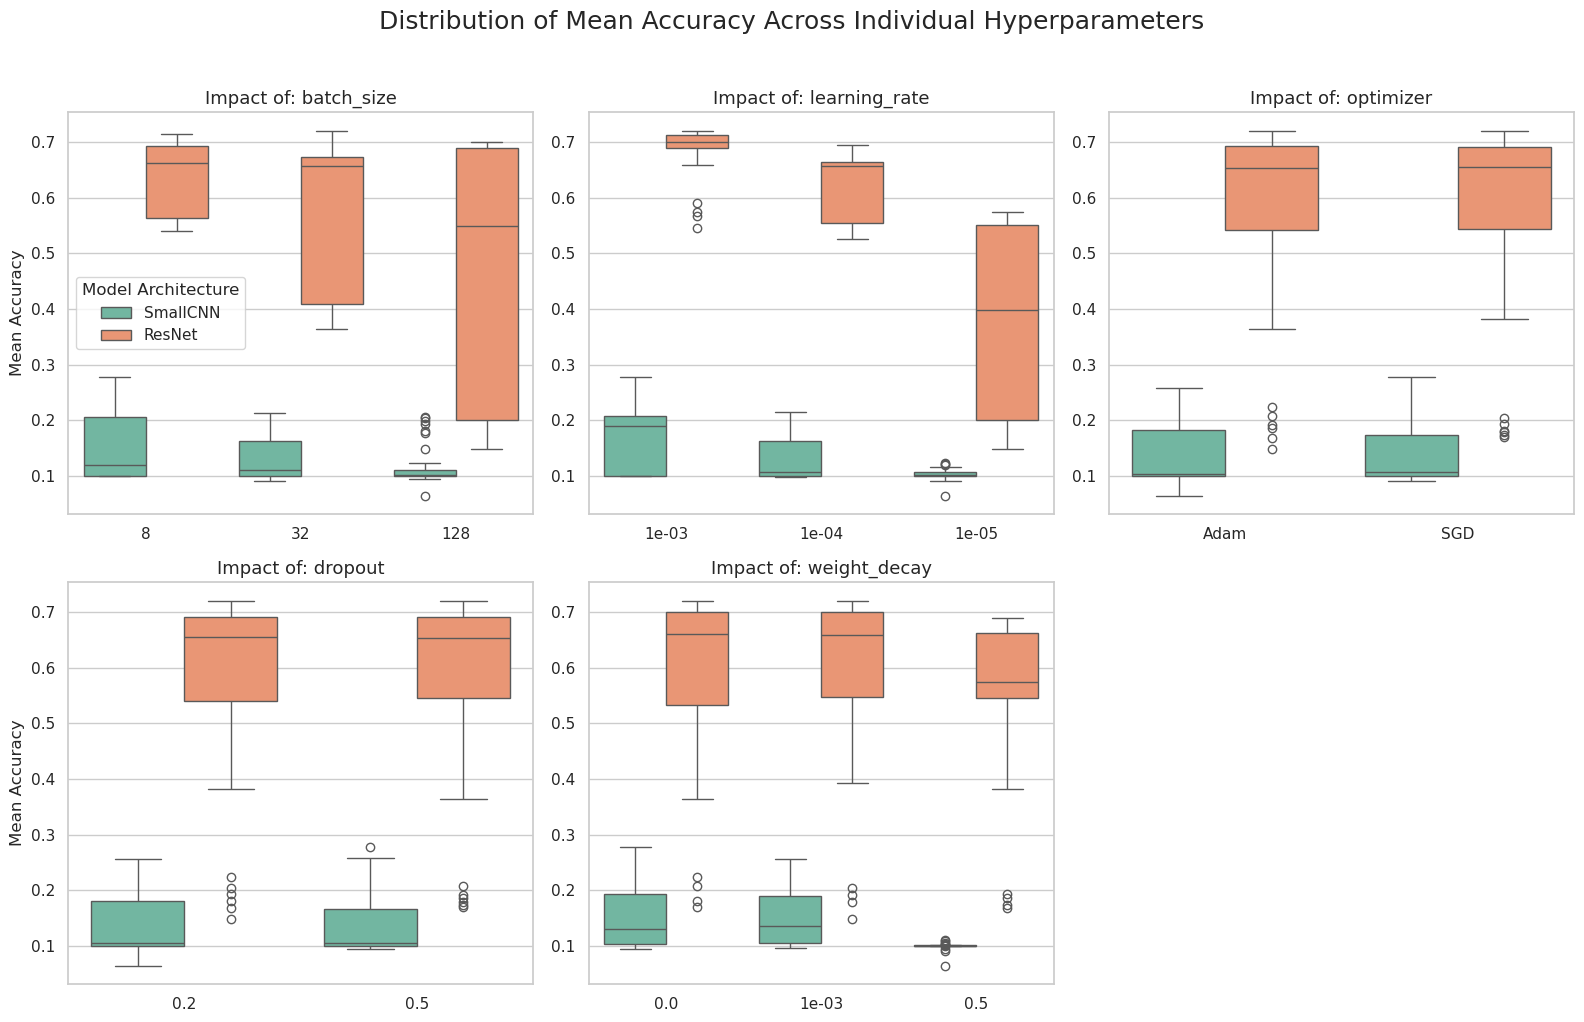

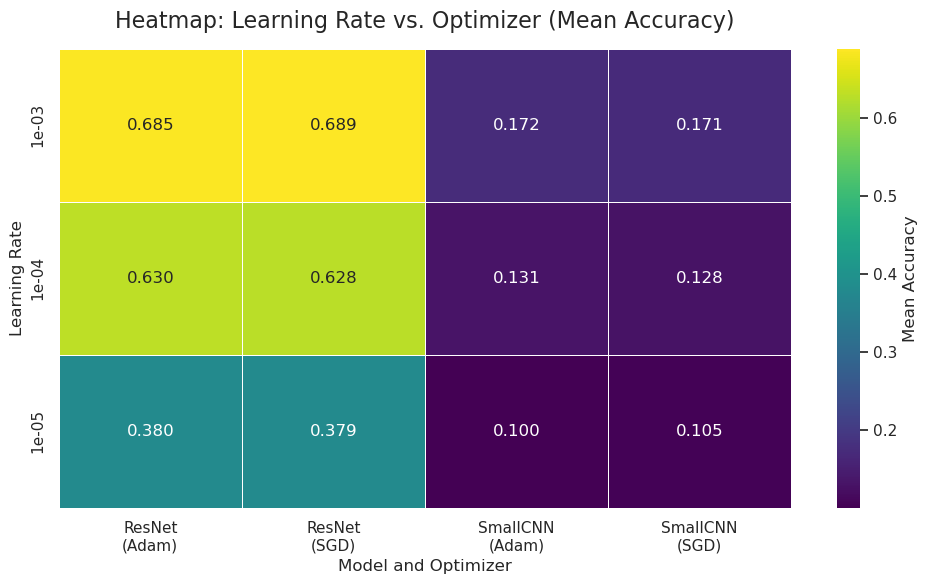

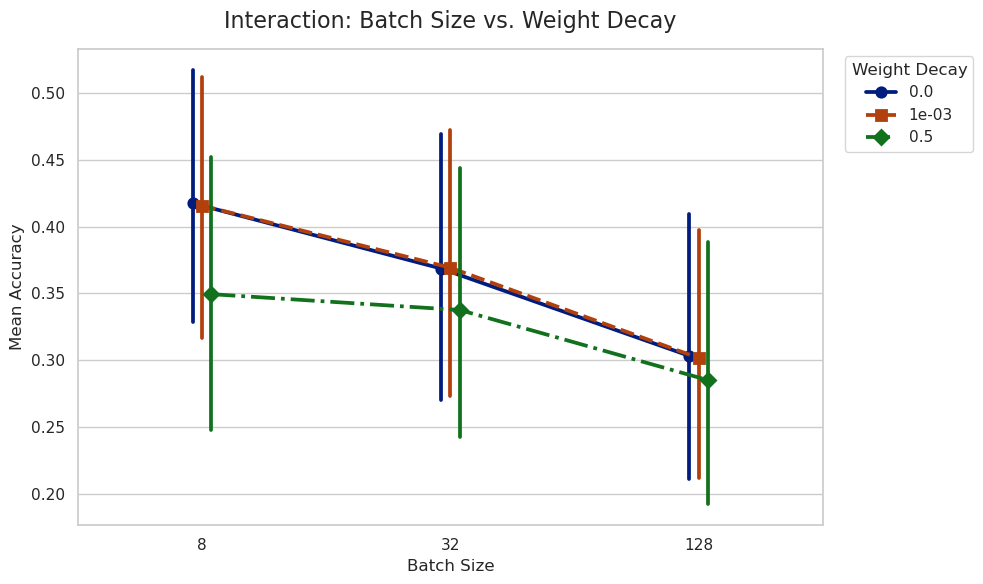

In [ ]:
sns.set_theme(style="whitegrid", palette="muted")

def prepare_and_plot_hyperparameters(df, metric="mean_acc"):
    metric_label = "Mean Accuracy" if metric == "mean_acc" else metric

    print("Unpacking configurations for plotting...")
    df_plot = df.copy()
    
    df_plot['config_dict'] = df_plot['config'].apply(ast.literal_eval)
    
    config_expanded = df_plot['config_dict'].apply(pd.Series)
    
    df_expanded = pd.concat([df_plot, config_expanded], axis=1)
    
    df_expanded['learning_rate'] = df_expanded['learning_rate'].apply(lambda x: f"{x:.0e}")
    df_expanded['weight_decay'] = df_expanded['weight_decay'].apply(lambda x: f"{x:.0e}" if isinstance(x, (int, float)) and 0 < x < 0.1 else str(x))

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle(f"Distribution of {metric_label} Across Individual Hyperparameters", fontsize=18, y=1.02)
    
    params = ["batch_size", "learning_rate", "optimizer", "dropout", "weight_decay"]
    axes = axes.flatten() 
    
    for i, param in enumerate(params):
        sns.boxplot(
            data=df_expanded, 
            x=param, 
            y=metric, 
            hue="model", 
            ax=axes[i],
            palette="Set2"
        )
        
        axes[i].set_title(f"Impact of: {param}", fontsize=13)
        axes[i].set_xlabel("")
        axes[i].set_ylabel(metric_label if i % 3 == 0 else "")
        
        if i > 0:
            axes[i].get_legend().remove()
        else:
            axes[i].legend(title="Model Architecture")
            
    fig.delaxes(axes[5])
    
    plt.tight_layout()
    plt.savefig("figures/plot_hyperparams_1_boxplots.png", dpi=300, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(10, 6))
    
    pivot_df = df_expanded.pivot_table(
        index='learning_rate', 
        columns=['model', 'optimizer'], 
        values=metric, 
        aggfunc='mean'
    )
    
    pivot_df.columns = [f"{col[0]}\n({col[1]})" for col in pivot_df.columns]
    
    sns.heatmap(
        pivot_df, 
        annot=True,      
        fmt=".3f",       
        cmap="viridis",  
        linewidths=.5,
        cbar_kws={'label': metric_label}
    )
    
    plt.title(f"Heatmap: Learning Rate vs. Optimizer ({metric_label})", fontsize=16, pad=15)
    plt.ylabel("Learning Rate", fontsize=12)
    plt.xlabel("Model and Optimizer", fontsize=12)
    
    plt.tight_layout()
    plt.savefig("figures/plot_hyperparams_2_heatmap.png", dpi=300, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(10, 6))
    
    sns.pointplot(
        data=df_expanded, 
        x="batch_size", 
        y=metric, 
        hue="weight_decay", 
        dodge=True,    
        markers=["o", "s", "D"],
        linestyles=["-", "--", "-."],
        palette="dark" 
    )
    
    plt.title("Interaction: Batch Size vs. Weight Decay", fontsize=16, pad=15)
    plt.xlabel("Batch Size", fontsize=12)
    plt.ylabel(metric_label, fontsize=12)
    plt.legend(title="Weight Decay", bbox_to_anchor=(1.02, 1), loc='upper left')
    
    plt.tight_layout()
    plt.savefig("figures/plot_hyperparams_3_pointplot.png", dpi=300, bbox_inches='tight')
    plt.show()

prepare_and_plot_hyperparameters(small_data_results, metric="mean_acc")